#Домашня робота №1
##ФБ-42 Кисельова Єлизавета

In [6]:
import pandas as pd
import numpy as np

Датасет взятий із сайту: https://www.kaggle.com/datasets/saitejabandaruin/imdb-top-700-movies-2026-edition?select=global_tech_startups_2026.csv

In [7]:
import pandas as pd

file_name = r'global_tech_startups_2026.csv'

df = pd.read_csv(
    file_name,
    sep=",",
    na_values='?'
)

df

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,00571113,SpaceTech,2020,USA,Austin,Series B,21.00,86.55,3.96,1.20,16.2,111,43,68,Tier 3 (Angel/Seed),High,Independent
24996,AFA8F35C,Cybersecurity,2017,UK,Oxford,Series B,29.38,316.21,16.36,3.11,9.2,214,99,115,Tier 2 (Mid-size VC),High,Independent
24997,0EEEA516,Web3/Crypto,2021,Singapore,Singapore,Series B,7.84,57.81,3.79,0.31,19.1,29,0,29,Tier 3 (Angel/Seed),High,Independent
24998,586B1BAF,ClimateTech,2020,Singapore,Singapore,Series A,0.00,33.67,1.96,0.45,0.0,41,0,41,Bootstrapped,High,Independent


Знаходження рядків без даних (зі значенням NaN)

In [8]:
df.isna().sum()

Company_ID                       0
Domain                           0
Founding_Year                    0
Country                          0
City                             0
Funding_Stage                    0
Total_Funding_USD_Millions       0
Valuation_USD_Millions           0
Revenue_ARR_Millions             0
Monthly_Burn_Rate_Millions       0
Runway_Months_2024               0
Peak_Headcount_2023              0
Layoffs_2024_2025                0
Current_Headcount_2026           0
Investor_Tier                    0
AI_Adoption_Level             2592
Acquisition_Status               0
dtype: int64

In [9]:
df_clean = df.dropna() #видалення рядків з NaN
len(df_clean) #виводимо кількість рядків що залишилась (25000-2592)

22408

In [10]:
df_clean.to_csv("clean_global_tech_startups_2026.csv", index=False) #завантажую чистий датасет


Порахувати середнє, усічене середнє, медіану, дисперсією, стандартне відхилення, середнє відхидення, абсолютно медіане відхилення. 
Виконую з рядком Founding_Year

In [11]:
col = "Founding_Year"

# Беремо числові значення
data = pd.to_numeric(df_clean[col], errors='coerce').dropna()

# 1. Середнє
mean_value = data.mean()

# 2. Усічене середнє (trimmed mean) — відсікаємо 10% з кожного краю
lower_q = data.quantile(0.10)
upper_q = data.quantile(0.90)
trimmed_data = data[(data >= lower_q) & (data <= upper_q)]
trimmed_mean_value = trimmed_data.mean()

# 3. Медіана
median_value = data.median()

# 4. Дисперсія
variance_value = data.var()

# 5. Стандартне відхилення
std_value = data.std()

# 6. Середнє абсолютне відхилення (Mean Absolute Deviation)
mad_mean_value = (data - mean_value).abs().mean()

# 7. Абсолютне медіанне відхилення (Median Absolute Deviation)
mad_median_value = (data - median_value).abs().median()

mean_value, trimmed_mean_value, median_value, variance_value, std_value, mad_mean_value, mad_median_value

(np.float64(2018.9115048197073),
 np.float64(2019.161839678924),
 np.float64(2019.0),
 np.float64(7.908132014882828),
 np.float64(2.812140112953625),
 np.float64(2.2105050651951292),
 np.float64(2.0))

Нормалізувати дані мін. мах та середня нормалізація.


In [12]:
df.to_csv('serednya_data.csv', index=False)

print('Нормалізовані дані збережено у файл serednya_data.csv')

Нормалізовані дані збережено у файл serednya_data.csv


In [13]:
import pandas as pd

df = pd.read_csv('global_tech_startups_2026.csv')

column = 'Total_Funding_USD_Millions'

data = df[column].dropna()

min_value = data.min()
max_value = data.max()

mean_value = data.mean()

df['Min_Max_Normalization'] = (
    (df[column] - min_value) / (max_value - min_value)
)

df['Mean_Normalization'] = (
    (df[column] - mean_value) / (max_value - min_value)
)

df[[column, 'Min_Max_Normalization', 'Mean_Normalization']].head(10)

,Total_Funding_USD_Millions,Min_Max_Normalization,Mean_Normalization
0,1.64,0.000208,-0.007371
1,103.87,0.013203,0.005623
2,10.08,0.001281,-0.006298
3,32.28,0.004103,-0.003477
4,13.41,0.001705,-0.005875
5,287.28,0.036515,0.028936
6,6.55,0.000833,-0.006747
7,2.16,0.000275,-0.007305
8,33.93,0.004313,-0.003267
9,23.80,0.003025,-0.004554


In [14]:
df.to_csv('normalized_data.csv', index=False)

print('Нормалізовані дані збережено у файл normalized_data.csv')

Нормалізовані дані збережено у файл normalized_data.csv


In [17]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\liiso\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


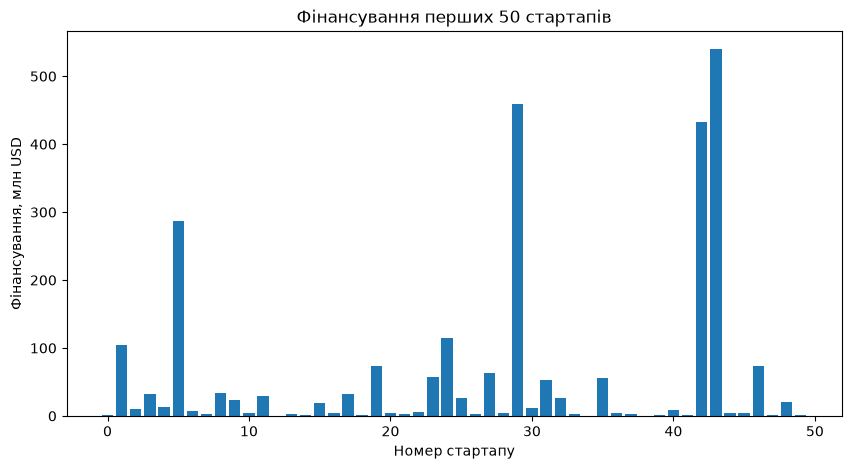

In [20]:
import matplotlib.pyplot as plt

data = df['Total_Funding_USD_Millions'].dropna().head(50)

plt.figure(figsize=(10, 5))
plt.bar(range(len(data)), data)

plt.title('Фінансування перших 50 стартапів')
plt.xlabel('Номер стартапу')
plt.ylabel('Фінансування, млн USD')

plt.show()

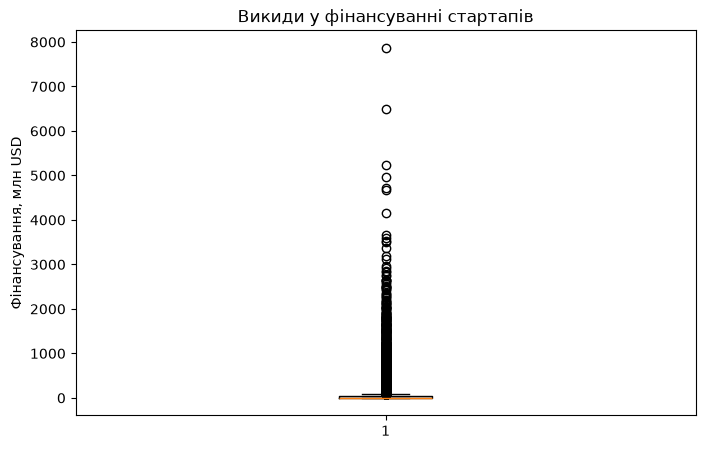

In [21]:
import matplotlib.pyplot as plt

data = df['Total_Funding_USD_Millions'].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot(data)

plt.title('Викиди у фінансуванні стартапів')
plt.ylabel('Фінансування, млн USD')

plt.show()

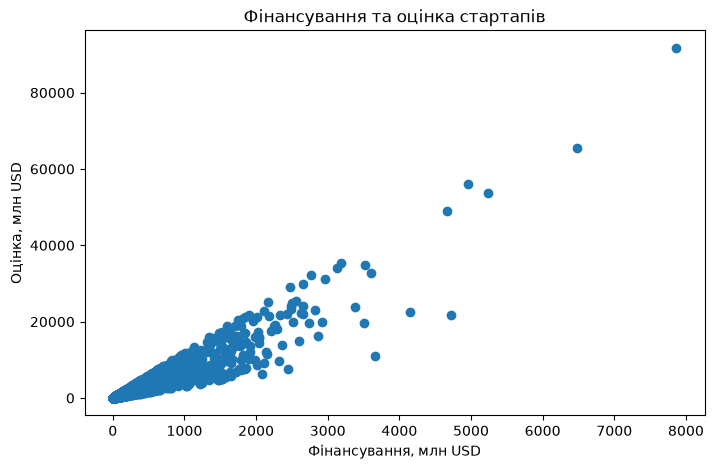

In [22]:
import matplotlib.pyplot as plt

x = df['Total_Funding_USD_Millions']
y = df['Valuation_USD_Millions']

plt.figure(figsize=(8, 5))
plt.scatter(x, y)

plt.title('Фінансування та оцінка стартапів')
plt.xlabel('Фінансування, млн USD')
plt.ylabel('Оцінка, млн USD')

plt.show()